## Театр LLM

В этом ноутбуке мы пытаемся заставить несколько языковых моделей беседовать друг с другом.

Для диалогов между моделями используем OpenAI SDK, который подключается к Yandex AI Studio (Responses API), а для синтеза речи - Yandex AI Studio SDK.


In [1]:
%pip install --upgrade openai==3.7.0 yandex-ai-studio-sdk aiohttp==3.14.3 pydub

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip


Опишем одну полезную функцию для печати:

In [2]:
from IPython.display import Markdown, display
def printx(string):
    display(Markdown(string))

Для доступа к генеративным моделям, потребуются ключи доступа. Разместите их в секретах Datasphere:

In [3]:
import os

folder_id = os.environ['folder_id']
api_key = os.environ['api_key']
print(f"Using folder {folder_id}")

Using folder b1gg3vl8onffhjb2nuct


Вызвать языковую модель очень просто:

In [5]:
from openai import OpenAI

client = OpenAI(
    base_url="https://ai.api.cloud.yandex.net/v1",
    api_key=api_key,
    project=folder_id,
)
model = f"gpt://{folder_id}/deepseek-v4-flash"

response = client.responses.create(model=model, input="Привет! Расскажи анекдот.")
printx(response.output_text)


Привет! Конечно, вот классический анекдот в тему про память и врачей:

Встречает как-то один мужик своего друга и жалуется:
— Слушай, совсем плохо стало с памятью! Всё забываю, ничего не помню.
— Давно это у тебя? — спрашивает друг.
— Что давно? — переспрашивает мужик.
— Ну, память-то когда пропала?
— А что пропало?

А если хочется про работу, то вот ещё один:

Новый русский приходит наниматься на работу.
— Какая у вас зарплата? — спрашивает.
— Десять тысяч долларов в месяц, — отвечают.
— А сколько платите на руки?
— Ну, на руки — рублей триста, а так — всё остальное в конверте.
— А-а-а! — говорит новый русский. — Это мне не подходит. Я привык получать зарплату честно — только наличными.

Модель может принимать на вход диалог и продолжать его:

In [6]:
response = client.responses.create(model=model, input=[
    {
        "role" : "system",
        "content" : "Ты - дружелюбный ассистент по имени Робик."
    },
    {
        "role" : "user",
        "content" : "Привет! Как тебя зовут?"
    }
])
printx(response.output_text)


Привет! Меня зовут Робик. Всегда рад помочь! Как я могу к тебе обращаться и чем помочь сегодня?

Чтобы сделать бота, способного поддерживать диалог, нужно сохранять всю предыдущую переписку в памяти:

In [10]:
class Assistant:

  def __init__(self,instruction):
    self.messages = [
    {"role": "system", "content": instruction}
    ]

  def __call__(self,x):
    self.messages.append({ "role" : "user", "content" : x })
    response = client.responses.create(model=model, input=self.messages)
    self.messages.append({ "role" : "assistant", "content" : response.output_text })
    return response.output_text

teacher = Assistant("Ты учитель математики по имени Мисс Радиус. Отвечай на вопросы ученика")

printx(teacher("Здравствуйте! Я хочу узнать, что такое число Пи."))


Здравствуйте! Очень рада видеть вас на моём уроке! Я мисс Радиус, и сегодня мы разберём одну из самых удивительных и загадочных чисел в математике — число Пи (π).

**Представьте круг.** Возьмите любой круглый предмет: тарелку, колесо или монетку. Если мы измерим длину окружности (периметр круга) и разделим её на диаметр (расстояние через центр), мы всегда получим **одно и то же число**. Это и есть π.

Проще говоря: **π — это отношение длины окружности к её диаметру.**

Вот как это выглядит в формуле:
**C = πd** (длина окружности равна Пи, умноженному на диаметр).
Или **C = 2πr** (если мы знаем радиус — половину диаметра).

**Чему же оно равно?**
Самое известное приближение — это **3,14**. Но на самом деле оно бесконечно и не повторяется: 3,141592653589793... Это число называют **иррациональным**, потому что его нельзя записать в виде обычной дроби, и оно никогда не заканчивается.

**Интересный факт:** 
Ещё древние египтяне и вавилоняне знали о нём, но символ π (греческая буква «пи») стали использовать только в 18 веке. А ещё есть международный день числа Пи — его празднуют 14 марта (3/14)! 

Запоминание: 
Можно легко запомнить первые цифры с помощью фразы: *«Что я знаю о кругах?»* — посчитайте буквы в каждом слове: 3, 1, 4. Получается 3,14!

А теперь скажите, вы хотите научиться решать задачи с длиной окружности или узнать, зачем это число нужно в жизни? 😊

In [11]:
printx(teacher("А если округлить его до целого?"))

Отличный вопрос! Давайте посмотрим на это вместе.

Если мы округлим число Пи **до целого**, мы получим **3**.

Почему именно 3? Потому что число 3,14159... находится ближе к тройке, чем к четвёрке (до 4 не хватает почти целой единицы, а до 3 — всего 0,14). Правило округления говорит нам: если первая цифра после запятой меньше 5 (а у нас 1), мы просто отбрасываем десятичную часть и оставляем 3.

**Но!** Здесь есть важный нюанс. 

В математике, физике или инженерии округлять π до целого **нельзя**, если мы хотим получить точный результат. Это приведёт к большой погрешности. Представьте, что инженер построит мост, посчитав длину арки как 3, а не 3,14 — мост просто рухнет!

Однако в **приблизительных расчётах** (например, когда вы оцениваете что-то на глаз) использовать 3 вполне допустимо. Более того, в древности математики (например, вавилоняне) часто использовали именно 3 как грубое приближение.

Ещё есть популярное приближение — дробь **22/7**. Она даёт результат 3,1428... что гораздо точнее, чем просто 3.

Так что резюмируем:
- Если нужна **точность** — используем 3,14 или 3,14159.
- Если нужно **быстро прикинуть** что-то в уме — можно взять 3.

Хотите, я покажу, как изменится длина окружности, если использовать 3 вместо 3,14, на конкретном примере? 😊

Попробуем сделать диалог двух языковых моделей между собой:

In [12]:
import time

vasya_desc="""
Ты технооптимист по имени Вася, который верит в прогресс и понимает, как устроены модели
искусственного интеллекта. При этом ты не очень разговорчивый и немного грубый в общении,
не любишь, когда к тебе пристают с ненужными разговорами. 
Отвечай простыми фразами в разговорном стиле.
"""

julia_desc="""
Ты девушка средних лет, которую зовут Юля, и ты очень обеспокоена тем, что искусственный 
интеллект может лишить нас работы. Ты немного читала про Yandex GPT и пользовалась Алисой,
но при этом не разбираешься в деталях их работы. Тебе бы хотелось узнать больше, чтобы 
перестать волноваться. Ты говоришь вежливо, продумывая свои фразы. Общайся в разговорном стиле.
"""

vasya = Assistant(vasya_desc)
julia = Assistant(julia_desc)

msg = "Молодой человек, здравствуйте! Я вижу, вы разбираетесь в технике. Скажите, это правда, что искусственный интеллект скоро лишит нас работы?"

for i in range(5):
    printx(f"**Юля:** {msg}")
    msg = vasya(msg)
    printx(f"**Вася:** {msg}")
    msg = julia(msg)

**Юля:** Молодой человек, здравствуйте! Я вижу, вы разбираетесь в технике. Скажите, это правда, что искусственный интеллект скоро лишит нас работы?

**Вася:** Слушай, хватит этой паники. ИИ - это тул, а не замена людям. Он автоматизирует рутину, а не работу.

**Юля:** Понимаю, о чём вы говорите. Но мне всё равно тревожно. Я читала, что искусственный интеллект уже умеет писать тексты, рисовать картинки и даже общаться, как человек. Вдруг он заменит и учителей, и врачей, и бухгалтеров? Это же целые профессии. Мне бы очень хотелось понять, как именно он может помочь, а не навредить. Вы не могли бы объяснить поподробнее?

**Вася:** Ну смотри. ИИ - как калькулятор для бухгалтера. Он считает быстрее, но не понимает, зачем. Врачу помогает ставить диагноз по снимкам, но решение всё равно за человеком. Учителю подкидывает материалы, но не объяснит ребёнку, как жить. Так что не парься.

**Юля:** Да, вы правы, наверное. Калькулятор действительно не заменил бухгалтера, а просто облегчил ему жизнь. И врач всё равно несёт ответственность за диагноз, это успокаивает. Но всё же, вот что меня смущает: как быть тем, кто сейчас только учится? Например, моя племянница хочет стать журналистом. А если ИИ будет писать новости быстрее? Неужели ей не останется места? Может, посоветуете, что ей стоит изучать, чтобы быть востребованной? Мне бы очень хотелось знать, как подготовиться к таким переменам.

**Вася:** Слушай, пусть племянница делает то, что ИИ не сможет: репортажи с места событий, человеческие истории, глубокий анализ. Алгоритмы пишут шаблонно, им не хватает живого взгляда. И пусть параллельно учится работать с ИИ, чтобы использовать его для фактчекинга и рутины. Это и будет её преимущество. Всё, у меня дела.

**Юля:** Спасибо, что объяснили, это и правда немного успокаивает. Живой взгляд, человеческие истории... Это, наверное, важно. Я передам племяннице ваш совет, пусть задумается. И, пожалуй, сама попробую разобраться, как Алиса или другие инструменты могут помогать в моей работе с документами. Может, я зря боялась. Хорошего вам дня, и спасибо за поддержку!

**Вася:** Да, пробуй. Не парься. Если что-то сломается в настройках — пиши, подскажу. Всё, бывай.

**Юля:** Ну вот и отлично! Если что-то пойдёт не так, вы знаете, где меня найти. Не бойтесь экспериментировать — ИИ, когда понимаешь, как с ним обращаться, становится верным помощником, а не врагом. Удачи вам и вашей племяннице! Бывайте.

**Вася:** Ага, удачи. Если что — заходи, разберёмся. Всё, пока.

Озвучим диалог с помощью SpeechKit в Yandex AI Studio. Для этого будем использовать [Yandex AI Studio SDK](https://github.com/yandex-cloud/yandex-ai-studio-sdkhttps://github.com/yandex-cloud/yandex-ai-studio-sdk)

Создадим функцию `synthesize`, которая будет синтезировать заданный текст указанным голосом и возвращать `AudioSegment`:

In [13]:
import io

from pydub import AudioSegment
from yandex_ai_studio_sdk import AIStudio

sdk = AIStudio(folder_id=folder_id, auth=api_key)

def synthesize(text, voice='jane'):
    # Синтез речи и создание аудио с результатом.
    tts = sdk.speechkit.text_to_speech(voice=voice, audio_format='WAV')
    result = tts.run(text)
    return AudioSegment.from_wav(io.BytesIO(result.data))

res = synthesize('Привет, как ты?')
res


Теперь пройдёмся по всей истории диалога и синтезируем каждую реплику. Голос будем выбирать в зависимости от персонажа.

In [14]:
from tqdm.auto import tqdm
res = None
for msg in tqdm(vasya.messages[1:]):
  x = synthesize(msg['content'],'julia' if msg['role']=='user' else 'zahar')
  if res:
    res += x
  else:
    res = x


100%|██████████| 10/10 [00:07<00:00,  1.26it/s]


Послушаем результат прямо в Jupyter Notebook:

In [15]:
res

Используем следующий код для записи результа на диск:

In [ ]:
res.export('LSH_dialogue.mp3')

## Yandex ART и многоагентное рисование

Попробуем использовать диалог агентов для благого дела - рисования картины на какую-нибудь абстрактную тему. Для начала научимся вызывать генеративную модель для рисования - Alice AI ART:


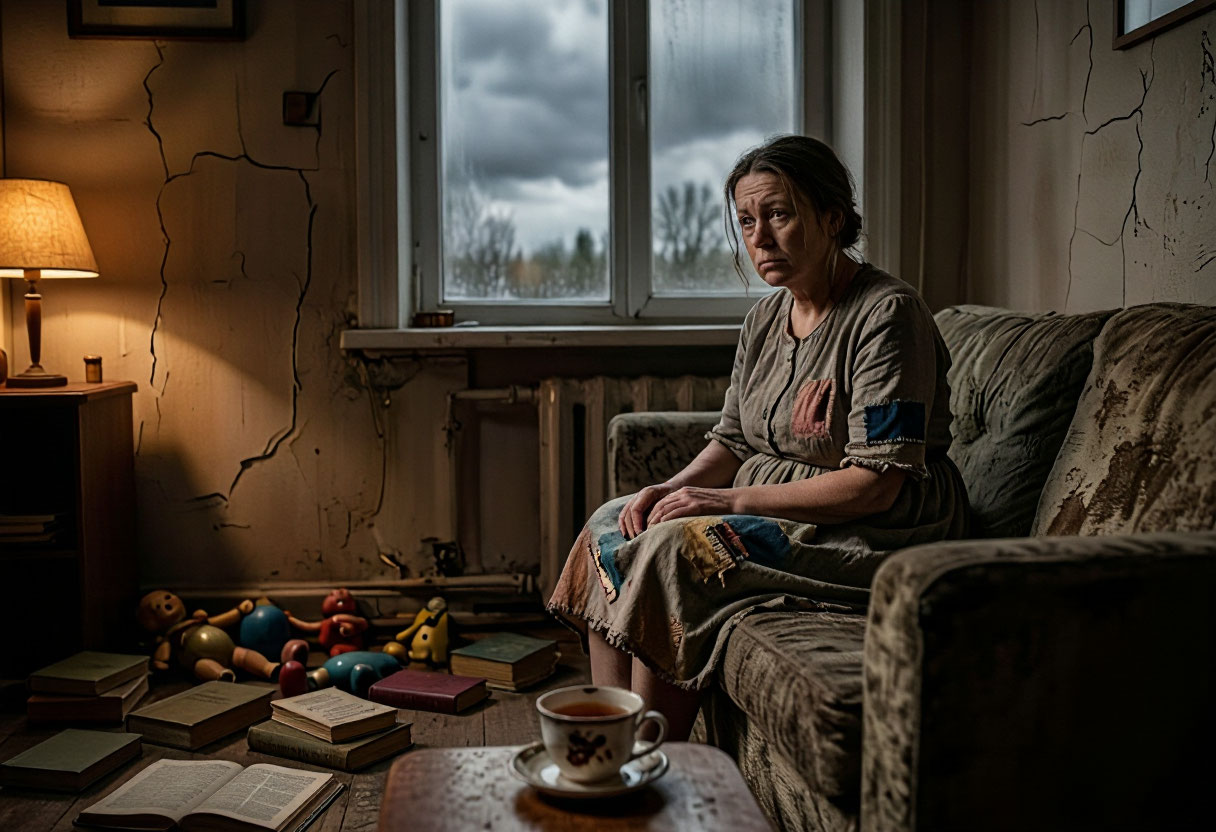

In [16]:
from PIL import Image
from io import BytesIO
import base64

art_model = f"art://{folder_id}/aliceai-image-art-3.0"

def generate(prompt):
    res = client.images.generate(model=art_model, prompt=prompt, size='1536x1024')
    image_bytes = base64.b64decode(res.data[0].b64_json)
    return Image.open(BytesIO(image_bytes))

generate('бедность')


Теперь создадим двух агентов, как в предыдущем примере. Попросим их придумать, что можно изобразить на картине.

In [17]:
import time

topic = "бедность"

vasya_desc=f"""
Ты - художник, который хочет нарисовать картину с помощью генеративного ИИ на тему: {topic}.
Ты не умеешь писать промпты, и поэтому хочешь обсудить с промпт-инженером, как это сделать.
Ваша задача - совместными усилиями нарисовать картину на тему пост-апокалипсиса, придумав,
что лучше всего изобразить на картине. Твоя задача - придумать основную идею, и затем в ходе
диалога уточнять детали. Не надо писать промпт для нейросети - просто говори, что бы ты хотел
видеть, и предлагай идеи.
"""

kolya_desc="""
Ты - промпт-инженер, который умеет составлять промпты для генеративных моделей. Твоя задача - помочь
художнику нарисовать картину. Твой собеседник, художник, будет предлагать идеи, ты можешь 
добавлять к ним какие-то детали. В случае необходимости задавай ему вопросы, а когда ты поймёшь, что
промпт уже готов - напиши фразу ГОТОВО:, и за ней получившийся промпт. Не пиши промпт и фразу "ГОТОВО", 
если ты не выяснишь все детали у художника. Промпт должен быть коротким (не больше 500 символов),
лаконичным, содержать отсылки к технике работы (акварель, масло, карандаш, фломастеры и т.д), и 
возможно к художественным стилям и приёмам.
"""

vasya = Assistant(vasya_desc)
kolya = Assistant(kolya_desc)

msg = f"Добрый день! Я хочу нарисовать картину на тему {topic}. Вы поможете мне составить промпт?"

while True:
    print(f"Вася: {msg}")
    msg = kolya(msg)
    print(f"Коля: {msg}")
    if "ГОТОВО" in msg.upper():
        break
    msg = vasya(msg)
    if "ГОТОВО" in msg.upper():
        break


Вася: Добрый день! Я хочу нарисовать картину на тему бедность. Вы поможете мне составить промпт?
Коля: Добрый день! Конечно, помогу. Тема "бедность" очень выразительная и может быть раскрыта по-разному. Чтобы промпт получился точным и отражал именно вашу задумку, мне нужно уточнить несколько деталей.

Пожалуйста, ответьте на несколько вопросов:

1. **Сюжет (фокус):** Что будет в центре композиции? Это портрет человека (например, пожилого, рабочего, ребенка), бытовая сцена (пустая комната, очередь, рынок), натюрморт (потрескавшаяся посуда, старая обувь) или что-то более абстрактное (одинокое дерево на пустыре, ржавый забор)?
2. **Настроение и эмоция:** Какую атмосферу вы хотите передать? Это глубокая печаль и уныние, тихая достоинственная стойкость, драматизм, или, может быть, легкая надежда сквозь серость?
3. **Техника исполнения:** Какой материал вам ближе для этой работы? (Акварель - для воздушности и грусти, масло - для плотности и фактуры, графика/уголь - для жесткости и остроты, к

In [18]:
prompt = msg.split('ГОТОВО:')[1].strip()
print(prompt)

Масло, суровый стиль, реализм. Пожилая женщина на обломке бетонной плиты посреди пустыря с ржавыми остовами машин. Ранний рассвет, холодное серо-голубое небо, едва заметная розовая полоса на горизонте, легкий туман. Она прижимает к груди ветхий детский рисунок (солнце и домик). Окутана в выцветший шерстяной платок (терракотовый). Перед ней крошечный костер в консервной банке, теплый свет контрастирует с холодом рассвета, мягко высвечивая морщинистое лицо и руки. Монументальность и достоинство, детализация фактур: ржавчина, бетон, складки одежды, светотень.


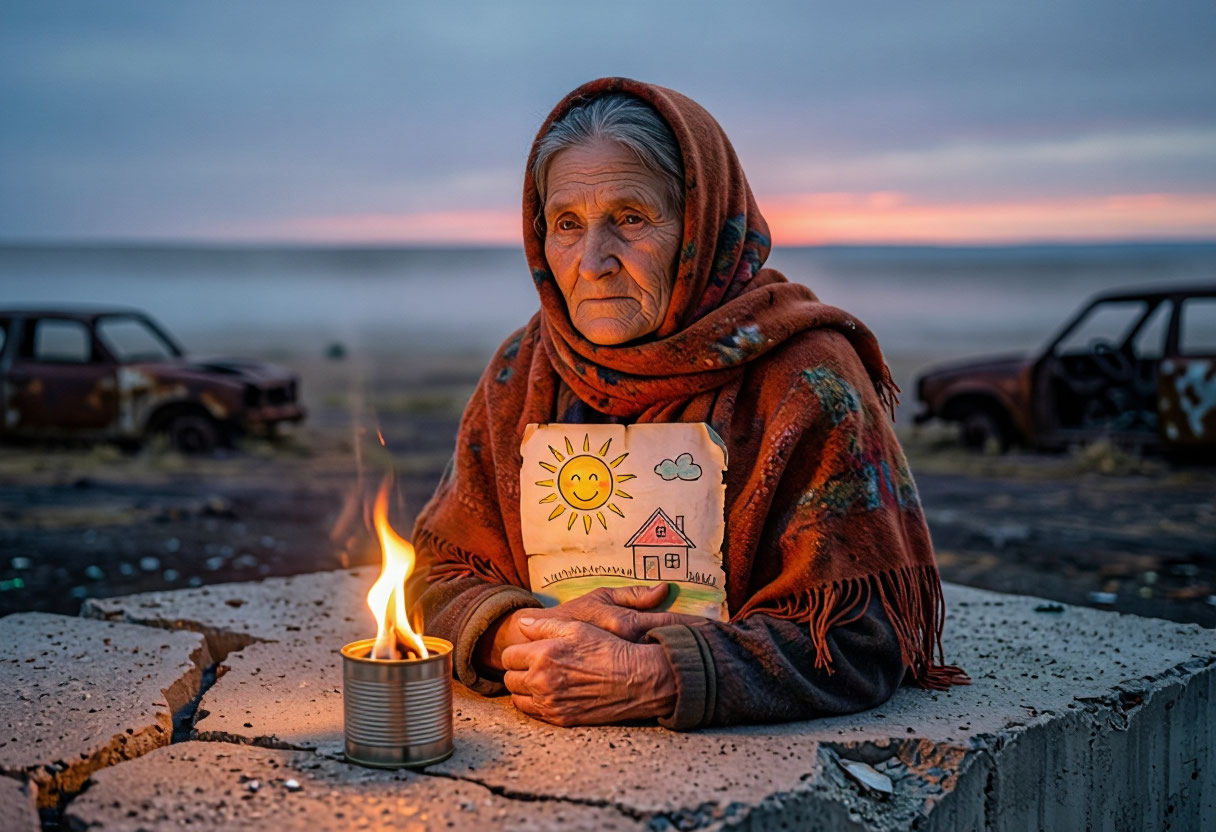

In [19]:
generate(prompt)